In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


In [2]:
# Q2 : Charger le fichier Churn_Modelling.csv dans un DataFrame nommé 'df'
df = pd.read_csv('Churn_Modelling.csv')

# Afficher les 5 premières lignes pour vérifier le chargement
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Q3 : Afficher un aperçu des données (Type, Non-null count, Mémoire)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
# Q4 : Donner la taille du dataSet (lignes, colonnes)
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 10000
Nombre de colonnes : 14


In [5]:
# Q5 : Afficher tous les noms de colonnes du DataFrame sous forme de liste
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [6]:
# Q6 : Supprimer les 3 premières colonnes (RowNumber, CustomerId, Surname)
# Ces colonnes sont des identifiants uniques qui n'aident pas le modèle à prédire le churn.
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Affichage des premières lignes après suppression
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [9]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
taux_churn = df['Exited'].mean() * 100
print(f"Taux de churn : {taux_churn:.2f}%")

Taux de churn : 20.37%


In [11]:
df.describe(include='object')

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


In [12]:
# Q13 : Donner le nombre de clients par pays (Geography)
print("Nombre de clients par pays :")
print(df['Geography'].value_counts())

Nombre de clients par pays :
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [13]:
# Q14 : Créer une liste contenant les noms des colonnes 'Balance' et 'EstimatedSalary'
my_list = ['Balance', 'EstimatedSalary']

print(f"Liste créée : {my_list}")

Liste créée : ['Balance', 'EstimatedSalary']


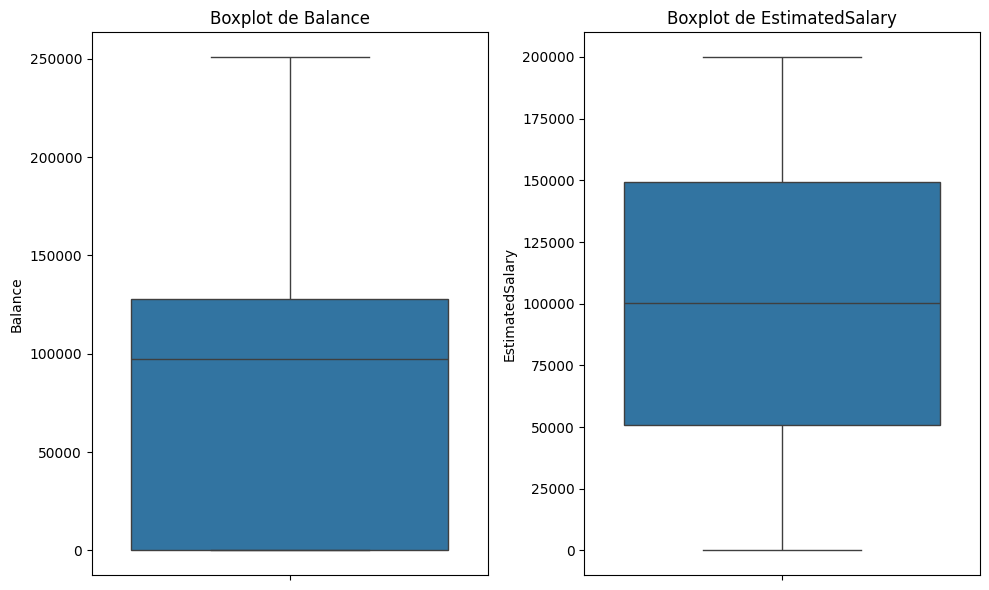

In [14]:
# Q15 : Afficher les Boxplots des variables contenues dans my_list
plt.figure(figsize=(10, 6)) # Taille de la figure

for i, col in enumerate(my_list, 1):
    plt.subplot(1, 2, i) # 1 ligne, 2 colonnes, i-ème graphique
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout() # Ajuste l'espacement pour éviter que les titres se chevauchent
plt.show()

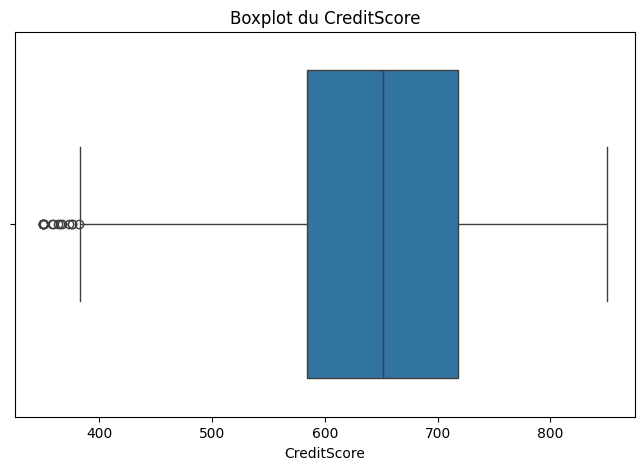

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['CreditScore'])
plt.title('Boxplot du CreditScore')
plt.show()

In [16]:
# Borne inférieure (Q1 - 1.5*IQR)
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)
IQR = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR

# Calcul du taux
taux = df[df['CreditScore'] <= borne_inf]['Exited'].mean() * 100
print(f"Taux de churn pour CreditScore <= borne inférieure : {taux:.2f}%")

Taux de churn pour CreditScore <= borne inférieure : 100.00%


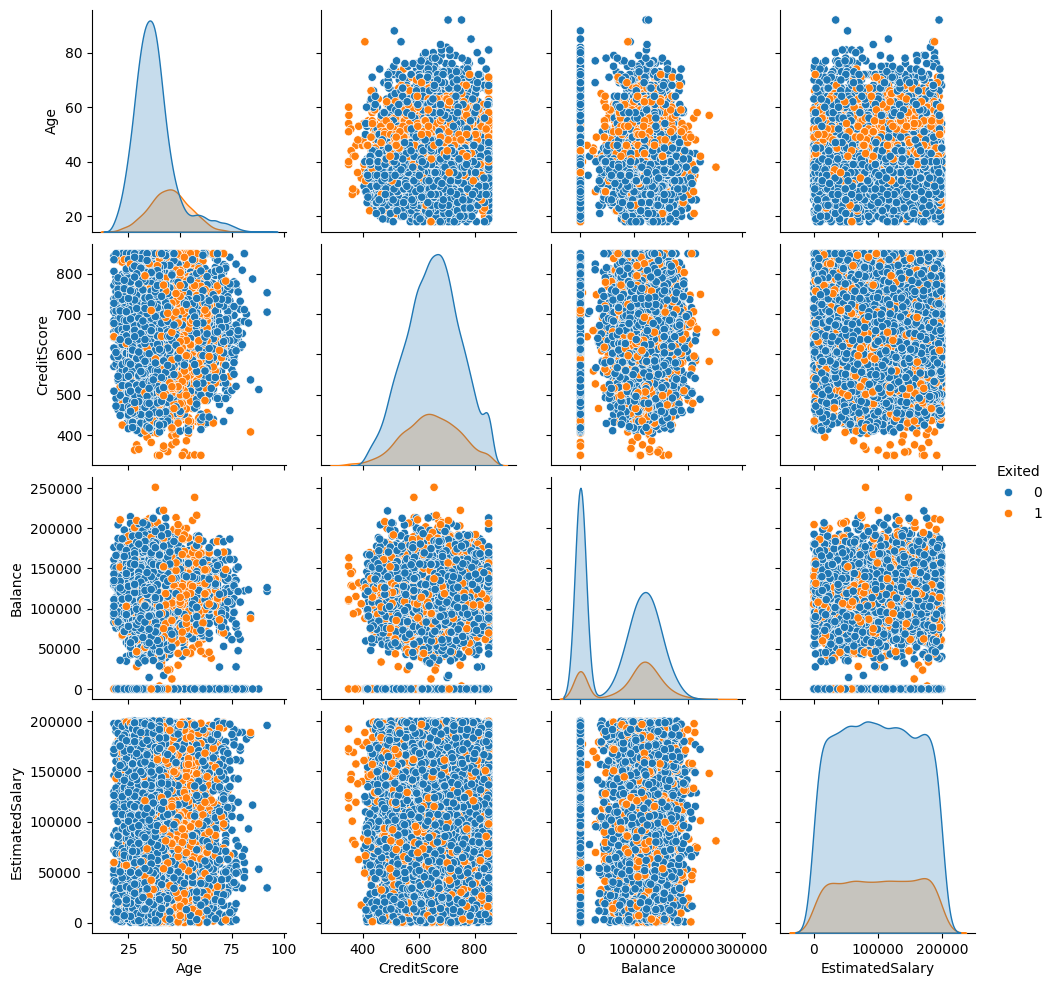

In [17]:
my_list = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary','Exited']
sns.pairplot(df[my_list], hue='Exited')

In [18]:
df.loc[(df['Age'].between(45, 55)), 'Exited'].mean() * 100

np.float64(48.701298701298704)

In [19]:
print(df.columns.tolist())
features = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
X = df[features]
y = df['Exited']
X.head()

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [20]:
X = X.values          
y = y.values

print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [21]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X[:,1] = encoder.fit_transform(X[:,1])


encoder = LabelEncoder()
X[:,2] = encoder.fit_transform(X[:,2])


In [ ]:
# ====================== ENCODAGE avec LabelEncoder ======================
from sklearn.preprocessing import LabelEncoder

# Encodage de Geography (colonne 1)
encoder_geo = LabelEncoder()
X[:, 1] = encoder_geo.fit_transform(X[:, 1])

# Encodage de Gender (colonne 2)
encoder_gen = LabelEncoder()
X[:, 2] = encoder_gen.fit_transform(X[:, 2])

print("Shape de X :", X.shape)


Encodage terminé
Shape de X : (10000, 10)
Types : object


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y          # Très important pour garder la même proportion de churn
)

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (8000, 10)
X_test shape  : (2000, 10)
y_train shape : (8000,)
y_test shape  : (2000,)


In [26]:
print(f"Taux de churn - Train : {y_train.mean()*100:.2f}%")
print(f"Taux de churn - Test  : {y_test.mean()*100:.2f}%")

Taux de churn - Train : 20.38%
Taux de churn - Test  : 20.35%


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   
X_test  = scaler.transform(X_test)        

In [ ]:
#scaler.inverse_transform(X_test)  # Pour revenir aux valeurs d'origine (optionnel)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

# Création du modèle KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Entraînement du modèle
knn.fit(X_train, y_train)

# Prédiction sur le test
y_pred_knn = knn.predict(X_test)

print("Modèle KNN entraîné avec succès")

Modèle KNN entraîné avec succès


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_range = range(3, 21, 2)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"Meilleur K = {best_k} avec F1 moyen = {max(cv_scores):.4f}")

Meilleur K = 3 avec F1 moyen = 0.4831


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1593
           1       0.66      0.39      0.49       407

    accuracy                           0.83      2000
   macro avg       0.76      0.67      0.69      2000
weighted avg       0.82      0.83      0.82      2000



In [39]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors' : [1,3,5,7,9,11,13]}
model= KNeighborsClassifier()
clf = GridSearchCV(model,parameters,scoring='accuracy', cv=5, verbose=3)
grille = clf.fit(X_train,y_train)
clf.fit
clf.fit(X_train, y_train)
print("Meilleur score : ", clf.best_score_)


Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .....................n_neighbors=1;, score=0.804 total time=   0.0s
[CV 2/5] END .....................n_neighbors=1;, score=0.804 total time=   0.0s
[CV 3/5] END .....................n_neighbors=1;, score=0.786 total time=   0.0s
[CV 4/5] END .....................n_neighbors=1;, score=0.796 total time=   0.0s
[CV 5/5] END .....................n_neighbors=1;, score=0.787 total time=   0.0s
[CV 1/5] END .....................n_neighbors=3;, score=0.820 total time=   0.0s
[CV 2/5] END .....................n_neighbors=3;, score=0.822 total time=   0.0s
[CV 3/5] END .....................n_neighbors=3;, score=0.813 total time=   0.0s
[CV 4/5] END .....................n_neighbors=3;, score=0.819 total time=   0.0s
[CV 5/5] END .....................n_neighbors=3;, score=0.835 total time=   0.0s
[CV 1/5] END .....................n_neighbors=5;, score=0.822 total time=   0.0s
[CV 2/5] END .....................n_neighbors=5;,